# Haplosaurus

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir(os.path.dirname(os.path.abspath('.')))

import pandas as pd
import src.haplosaurus as hs
import src.variant_annotation as va
import src.ESM as ESM
import src.ESM_predict as ESMp
import src.utils as utils
import src.gprofiler as gp
import src.ensembl_rest as er
from src.config import DATA_DIR 
import src.proteingym as pg
import src.biopython as bp

pd.set_option('display.max_columns', None)

In [36]:
refseq_map = er.get_refseq_map()
refseq_map = refseq_map.loc[refseq_map['db_name'] == 'RefSeq_peptide']
print(refseq_map.shape)
print(refseq_map.head())

tx_ids = refseq_map['transcript_stable_id'].unique().tolist()
print(len(tx_ids))

(75776, 9)
    gene_stable_id transcript_stable_id protein_stable_id          xref  \
0  ENSG00000142611      ENST00000378391   ENSP00000367643     NP_955533   
2  ENSG00000142611      ENST00000270722   ENSP00000270722     NP_071397   
4  ENSG00000157911      ENST00000288774   ENSP00000288774  NP_001361354   
5  ENSG00000157911      ENST00000288774   ENSP00000288774  NP_001361355   
6  ENSG00000157911      ENST00000288774   ENSP00000288774     NP_722540   

          db_name      info_type source_identity xref_identity linkage_type  
0  RefSeq_peptide         DIRECT             100           100            -  
2  RefSeq_peptide         DIRECT             100           100            -  
4  RefSeq_peptide  INFERRED_PAIR               -             -            -  
5  RefSeq_peptide  INFERRED_PAIR               -             -            -  
6  RefSeq_peptide         DIRECT             100           100            -  
47583


In [2]:
# haplotypes = hs.get_haplotypes(tx_ids=tx_ids)
haplotypes = hs.get_haplotypes(cache_only=True)
print(len(haplotypes))


Found 19481 haplotypes in: '/home/schilder/.cache/ensembl_rest/haplotypes'


Getting haplotypes:   0%|          | 0/19481 [00:00<?, ?it/s]

19481


## Get transcripts

In [2]:
candidate_proteins = utils.get_candidate_proteins()
print(candidate_proteins.shape)
proteins_df = pg.merge_resources()
print(proteins_df.shape)

(11, 6)


Gathering resources:   0%|          | 0/2 [00:00<?, ?it/s]

Gathering resources: 100%|██████████| 2/2 [00:00<00:00, 44.12it/s]

(4779, 9)


In [4]:
gp.map_ids(candidate_proteins, on_left='RefSeq Protein', target_namespace='ENSP')


,Gene,Protein Common Name,RefSeq Protein,RefSeq Transcript,RefSeq Protein Stable,ENSP,HGNC
0,G6PD,Glucose-6-phosphate 1-dehydrogenase,NP_001346945.1,NM_001360016.2,NP_001346945,ENSP00000358633,G6PD
1,G6PD,Glucose-6-phosphate 1-dehydrogenase,NP_001346945.1,NM_001360016.2,NP_001346945,ENSP00000377192,G6PD
2,G6PD,Glucose-6-phosphate 1-dehydrogenase,NP_001346945.1,NM_001360016.2,NP_001346945,ENSP00000377194,G6PD
3,G6PD,Glucose-6-phosphate 1-dehydrogenase,NP_001346945.1,NM_001360016.2,NP_001346945,ENSP00000394690,G6PD
4,G6PD,Glucose-6-phosphate 1-dehydrogenase,NP_001346945.1,NM_001360016.2,NP_001346945,ENSP00000395599,G6PD
...,...,...,...,...,...,...,...
152,KCNQ1,Potassium Voltage-Gated Channel Subfamily Q Me...,NP_000209.2,NM_000218.3,NP_000209,ENSP00000519029,KCNQ1
153,KCNH2,Potassium Voltage-Gated Channel Subfamily H Me...,NP_000229.1,NM_000238.4,NP_000229,ENSP00000262186,KCNH2
154,KCNH2,Potassium Voltage-Gated Channel Subfamily H Me...,NP_000229.1,NM_000238.4,NP_000229,ENSP00000328531,KCNH2
155,KCNH2,Potassium Voltage-Gated Channel Subfamily H Me...,NP_000229.1,NM_000238.4,NP_000229,ENSP00000519004,KCNH2


In [10]:
candidate_proteins2, proteins_df2 = gp.map_and_filter(candidate_proteins, 
                                                      proteins_df, 
                                                      input_col1="RefSeq Protein", 
                                                      input_col2="protein", 
                                                      target_namespace="ENSP")

Mapping df1 IDs to: ENSP
Running gprofiler.convert with 11 queries.
Loading ID mapping from: '/grid/koo/home/schilder/.cache/gprofiler/idmap_0cf9ab87affda3a5eb624b15954c7c99.csv.gz'
Saving ID mapping to: '/grid/koo/home/schilder/.cache/gprofiler/idmap_0cf9ab87affda3a5eb624b15954c7c99.csv.gz'
Dropping rows with NA in ['incoming', 'converted'].
Dropping all but 3 columns.
Mapping IDs to: ENSP
Mapping df2 IDs to: ENSP
Running gprofiler.convert with 3548 queries.
Loading ID mapping from: '/grid/koo/home/schilder/.cache/gprofiler/idmap_4e01cd7a938de7656636820051a7dd17.csv.gz'
Saving ID mapping to: '/grid/koo/home/schilder/.cache/gprofiler/idmap_4e01cd7a938de7656636820051a7dd17.csv.gz'
Dropping rows with NA in ['incoming', 'converted'].
Dropping all but 3 columns.
Mapping IDs to: ENSP
df1: Leaving only the first 1 rows per ID.
df2: Leaving only the first 1 rows per ID.


In [11]:
proteins_df2

,protein,RefSeq peptide ID,source_file,source_type,experiment_id,ENSP,HGNC
588,NP_009225.1,NP_009225,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_009225.1,ENSP00000312236,BRCA1
1185,NP_000401.1,NP_000401,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000401.1,ENSP00000259699,HFE
1819,NP_000229.1,NP_000229,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_000229.1,ENSP00000262186,KCNH2
1974,NP_000050.3,NP_000050,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_000050.3,ENSP00000369497,BRCA2
2292,NP_000286.3,NP_000286,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000286.3,ENSP00000348068,SERPINA1
3823,NP_000518.1,NP_000518,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000518.1,ENSP00000252444,LDLR
6495,NP_001346945.1,NP_001346945,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_001346945.1,ENSP00000358633,G6PD
17330,NP_000209.2,NP_000209,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_000209.2,ENSP00000155840,KCNQ1
23647,NP_000393.4,NP_000393,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000393.4,ENSP00000358633,G6PD
24144,NP_000509.1,NP_000509,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_000509.1,ENSP00000333994,HBB


In [ ]:
# Haplosaurus protein IDs
tx_df = pd.read_excel(DATA_DIR + "haplosaurus/41467_2018_6542_MOESM4_ESM.xlsx")
print(tx_df.shape)
# Bioconductor transcript to protein ID
tx_to_prot = pd.read_csv(DATA_DIR + "bioc/bioc_tx_to_prot.csv.gz")
print(tx_to_prot.shape)
tx_df = tx_df.merge(tx_to_prot.drop_duplicates(subset=['tx_id', 'protein_id']),
                    left_on="Ensembl Protein ID", 
                    right_on="protein_id", 
                    how="inner") 
print(tx_df.shape)
tx_df.head()

(20166, 6)
(109705, 9)
(18494, 15)


/grid/it/data/elzar/easybuild/software/Python/3.9.5-GCCcore-10.3.0/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3098: DtypeWarning: Columns (0) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,Ensembl Gene ID,Ensembl Protein ID,Gene Name,Number of Haplotypes,Number of Haplotypes FoO>=1%,Frequency Rank of Reference Protein Haplotype,seqnames,start,end,width,strand,protein_id,uniprot_id,tx_biotype,tx_id
0,ENSG00000121410,ENSP00000263100,A1BG,44,3.0,2.0,19,58346850,58353499,6650,-,ENSP00000263100,P04217,protein_coding,ENST00000263100
1,ENSG00000148584,ENSP00000363107,A1CF,25,2.0,1.0,10,50806562,50885675,79114,-,ENSP00000363107,Q9NQ94,protein_coding,ENST00000373995
2,ENSG00000175899,ENSP00000323929,A2M,69,5.0,10.0,12,9067712,9116157,48446,-,ENSP00000323929,P01023,protein_coding,ENST00000318602
3,ENSG00000166535,ENSP00000299698,A2ML1,171,9.0,10.0,12,8822472,8876785,54314,+,ENSP00000299698,A8K2U0,protein_coding,ENST00000299698
4,ENSG00000184389,ENSP00000475261,A3GALT2,34,1.0,1.0,1,33306766,33321098,14333,-,ENSP00000475261,U3KPV4,protein_coding,ENST00000442999


<AxesSubplot:>

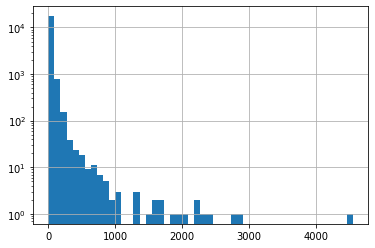

In [8]:
tx_df['Number of Haplotypes'].hist(bins=50, log=True)

In [9]:
# Remove MUC genes with lots of haplotypes as these may be artifacts
# tx_df = tx_df[(tx_df['Number of Haplotypes'] > 50) & (tx_df['Number of Haplotypes'] < 1000)]
# tx_df['Gene Name'].str.startswith('MUC')
tx_df.sort_values('Number of Haplotypes', ascending=False)
tx_ids = list(set(tx_df['tx_id'].tolist()))
tx_ids.reverse() # Start with the smallest number of haplotypes
# tx_ids = tx_ids[:5]

print(len(tx_ids),"transcripts")

18494 transcripts


## Get variant sets
Collect sets of variants (pathogenic, benign, 1KG) for each transcripts. 
Only trancripts with at least one pathogenic variant and one benign variant of the specifiied consequence type are included. Pathogenic/benign variants present in the 1KG cohort are excluded.

### Missense

In [10]:
variant_sets_dict = {
    ('SO:0001583','missense_variant'):{},
    ('SO:0001589','frameshift_variant'):{},
    ('SO:0001906','feature_truncation'):{}
    }

In [ ]:
for so_term, consequence_type in variant_sets_dict.keys():
    print(so_term, consequence_type)
    # Gather variant sets
    variant_sets_dict[(so_term, consequence_type)] = hs.get_variant_sets(
        tx_ids = tx_ids,
        so_term = so_term,
        consequence_type = consequence_type,
        # cache_only = cache_only, # Use cached files only (faster)
        error=False,
        # force=True
        )


In [21]:
# Get the number of transcripts with variant sets per consequence type
{k:len(v) for k,v in variant_sets_dict.items()}

{('SO:0001583', 'missense_variant'): 1070,
 ('SO:0001589', 'frameshift_variant'): 0,
 ('SO:0001906', 'feature_truncation'): 0}

## Get haplotypes


In [2]:
haplotypes = hs.get_haplotypes(
#     tx_ids=tx_ids, #variant_sets.keys(),  
    # max_tx_ids=5,
    cache_only=True, # Use cached files only (faster)
    # use_protein_ids=True,
    force=False
    )


Found 557 haplotypes in: '/home/schilder/.cache/ensembl_rest/haplotypes'


Getting haplotypes:   0%|          | 0/557 [00:00<?, ?it/s]

### Extract sequences

In [ ]:
cds_seqs = hs.get_haplotype_seqs(haplotypes,
                      key='cds_haplotypes',
                       aligned=0,
                       add_haplotype_names=2
                       )

utils.save_json(cds_seqs, DATA_DIR + 'cds_seqs.json')
cds_seqs


Getting haplotype sequences:   0%|          | 0/557 [00:00<?, ?it/s]

  0%|          | 0/557 [00:00<?, ?it/s]

Saving ==> /home/schilder/projects/data/cds_seqs.json with compression


In [25]:
cds_seqs_len = {tx_id:{hap_id:len(seq) for hap_id, seq in tx_haps.items()} for tx_id, tx_haps in cds_seqs.items()}

# Get min and max CDS sequence length per transcript
cds_seqs_min_max = {}
for tx_id, tx_haps in cds_seqs_len.items():
    if tx_haps:  # Check if dictionary is not empty
        min_len = min(tx_haps.values())
        max_len = max(tx_haps.values())
        cds_seqs_min_max[tx_id] = {
            'min_length': min_len,
            'max_length': max_len,
            'difference': max_len - min_len
        }

# Display results
print("Min and max CDS sequence lengths per transcript:")
for tx_id, stats in cds_seqs_min_max.items():
    print(f"{tx_id}: min={stats['min_length']}, max={stats['max_length']}, diff={stats['difference']}")


Min and max CDS sequence lengths per transcript:
ENST00000193391: min=3726, max=3726, diff=0
ENST00000254854: min=3306, max=3312, diff=6
ENST00000256646: min=7416, max=7416, diff=0
ENST00000261349: min=4842, max=4842, diff=0
ENST00000269571: min=3768, max=3768, diff=0


## Get reference haplotypes

In [15]:
haplotypes_ref = hs.get_haplotype_ref(haplotypes)
haplotypes_ref_seqs, missing_seqs = hs.get_haplotype_seqs(
    haplotypes_ref,
    return_missing=True,
    verbose=True)

(len(haplotypes), 
 len(haplotypes_ref), 
 len(haplotypes_ref_seqs),
 len(missing_seqs))


Processing transcripts:   0%|          | 0/402 [00:00<?, ?it/s]

  0%|          | 0/402 [00:00<?, ?it/s]

No seqs found for ENST00000359568
No seqs found for ENST00000324093
No seqs found for ENST00000405460
No seqs found for ENST00000354785


(402, 402, 398, 4)

## Add variants to haplotypes

In [ ]:
haplotypes_wt, haplotypes_pathogenic, haplotypes_benign = hs.add_variant_to_haplotypes(
  haplotypes=haplotypes, 
  variant_sets=variant_sets, 
  tx_ids=tx_ids,
  consequence_terms=['missense_variant'],
  max_transcripts=5,
  ref_checks=False,
  verbose=True
  )
# check length of each group
len(haplotypes_wt), len(haplotypes_pathogenic), len(haplotypes_benign)

In [17]:
print(hs.get_haplotype_counts(haplotypes_wt))
print(hs.get_haplotype_counts(haplotypes_pathogenic))
print(hs.get_haplotype_counts(haplotypes_benign))


{'ENST00000544455': 228, 'ENST00000220676': 122, 'ENST00000392403': 92, 'ENST00000300589': 105, 'ENST00000373818': 57}
{'ENST00000544455': 228, 'ENST00000220676': 122, 'ENST00000392403': 92, 'ENST00000300589': 105, 'ENST00000373818': 57}
{'ENST00000544455': 228, 'ENST00000220676': 122, 'ENST00000392403': 92, 'ENST00000300589': 105, 'ENST00000373818': 57}
